In [1]:
import kagglehub

path = kagglehub.dataset_download("shanegerami/ai-vs-human-text")

print("Dataset downloaded to:", path)

Mounting files to /kaggle/input/datasets/shanegerami/ai-vs-human-text...
Dataset downloaded to: /kaggle/input/datasets/shanegerami/ai-vs-human-text


loaded the dataset

In [2]:
import os

print(os.listdir(path))

['AI_Human.csv']


took a **balanced sample** because csv file is too large

In [4]:
human = df[df["generated"] == 0].sample(n=50000, random_state=42)
ai = df[df["generated"] == 1].sample(n=50000, random_state=42)

df = pd.concat([human, ai]).sample(frac=1, random_state=42).reset_index(drop=True)

df["generated"].value_counts()

generated
1.0    50000
0.0    50000
Name: count, dtype: int64

In [3]:
import pandas as pd
import os

file_path = os.path.join(path, "AI_Human.csv")

df = pd.read_csv(file_path)

print(df.shape)
df.head()

(487235, 2)


,text,generated
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0


check for **duplicates** and **nan**

In [6]:
print(df.shape)
print(df["generated"].value_counts())
print(df.isnull().sum())
print(df.duplicated().sum())
print(df["text"].duplicated().sum())

(100000, 2)
generated
1.0    50000
0.0    50000
Name: count, dtype: int64
text         0
generated    0
dtype: int64
0
0


In [7]:
print("HUMAN EXAMPLE:")
print(df[df["generated"] == 0]["text"].iloc[0])

print("\nAI EXAMPLE:")
print(df[df["generated"] == 1]["text"].iloc[0])

HUMAN EXAMPLE:
Dear President of the United States,

I think you should change the whole "

Electoral Collage

" and have election by a popular vote instead. It would make much more scence instead of the whole Congress blah, blah, blah, and stuff. I mean I know that this was created by our Founding Fathers and should show respect, but popular voting won't take as long and much faster too. It states that in the article on paragraph 3, the first sentence , "

The Electoral College consists on of 538 electors

". Thats a lot of people. But when people try to vote for you, they are actually voting for the candidate's electors.

"

Under the Electoral Collage System, when voters vote not for the president, but for the slate of electors, who in turn elect the president. If you lived in texas, for instance, and wanted to vote for [John] Kerry, you'd vote for the slate of 34 Democratic electores pleged to Kerry

" (

Par. #10, Sent. #1-2).

"

The Electoral College is what we might call a disa

split the dataset

In [8]:
X = df["text"]       #text
y = df["generated"]  #prediction

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100000,)
y shape: (100000,)


train/test split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      #train:80% , test:20%
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining labels:")
print(y_train.value_counts())

print("\nTesting labels:")
print(y_test.value_counts())

Training samples: 80000
Testing samples: 20000

Training labels:
generated
0.0    40000
1.0    40000
Name: count, dtype: int64

Testing labels:
generated
1.0    10000
0.0    10000
Name: count, dtype: int64


convert text to numbers

In [37]:
#1st model : Logistic Regression
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", LogisticRegression(max_iter=1000))
])

In [11]:
lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('model', LogisticRegression(max_iter=1000))])

In [12]:
y_pred = lr_pipeline.predict(X_test)

print(y_pred[:10])

[1. 0. 0. 1. 0. 0. 0. 0. 0. 1.]


evaluate

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9901
Precision: 0.9910821643286574
Recall: 0.9891
F1 Score: 0.9900900900900901


confusion matrix

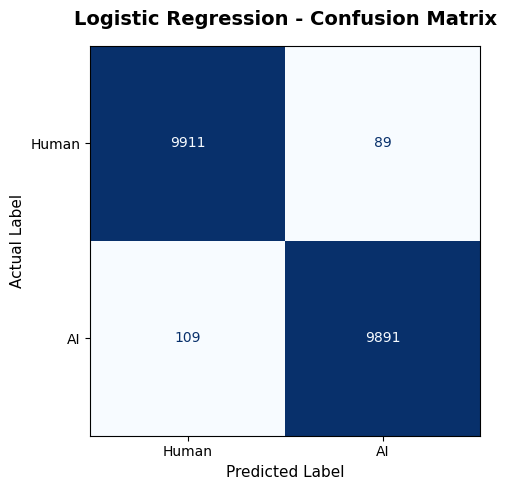

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Human", "AI"]
)

fig, ax = plt.subplots(figsize=(7, 5))

disp.plot(
    cmap="Blues",
    ax=ax,
    values_format="d",
    colorbar=False
)

plt.title(
    "Logistic Regression - Confusion Matrix",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("Actual Label", fontsize=11)

plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Human", "AI"]
))

              precision    recall  f1-score   support

       Human       0.99      0.99      0.99     10000
          AI       0.99      0.99      0.99     10000

    accuracy                           0.99     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       0.99      0.99      0.99     20000



In [39]:
#2nd model: svm
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", LinearSVC())
])

In [19]:
svm_pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('model', LinearSVC())])

In [20]:
y_pred_svm = svm_pipeline.predict(X_test)

print(y_pred_svm[:10])

[1. 0. 0. 1. 0. 0. 0. 0. 0. 1.]


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

print("Accuracy:", svm_accuracy)
print("Precision:", svm_precision)
print("Recall:", svm_recall)
print("F1 Score:", svm_f1)

Accuracy: 0.99545
Precision: 0.9956978489244622
Recall: 0.9952
F1 Score: 0.9954488622155538


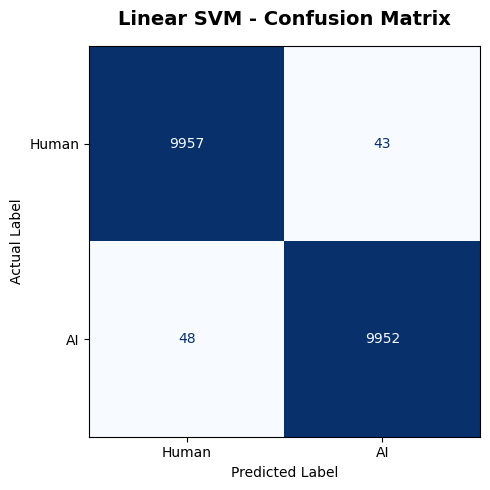

[[9957   43]
 [  48 9952]]


In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["Human", "AI"]
)

fig, ax = plt.subplots(figsize=(7, 5))

disp.plot(
    cmap="Blues",
    ax=ax,
    values_format="d",
    colorbar=False
)

plt.title(
    "Linear SVM - Confusion Matrix",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

print(cm_svm)

In [25]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_svm,
    target_names=["Human", "AI"],
    digits=4
))

              precision    recall  f1-score   support

       Human     0.9952    0.9957    0.9955     10000
          AI     0.9957    0.9952    0.9954     10000

    accuracy                         0.9954     20000
   macro avg     0.9955    0.9954    0.9954     20000
weighted avg     0.9955    0.9954    0.9954     20000



In [40]:
#3rd model: naive bayes
from sklearn.naive_bayes import MultinomialNB

nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", MultinomialNB())
])

In [30]:
nb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('model', MultinomialNB())])

In [31]:
y_pred_nb = nb_pipeline.predict(X_test)

print(y_pred_nb[:10])

[1. 0. 0. 1. 0. 0. 0. 0. 1. 1.]


In [32]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)

print("Accuracy:", nb_accuracy)
print("Precision:", nb_precision)
print("Recall:", nb_recall)
print("F1 Score:", nb_f1)

Accuracy: 0.945
Precision: 0.9735050010640561
Recall: 0.9149
F1 Score: 0.9432931230023713


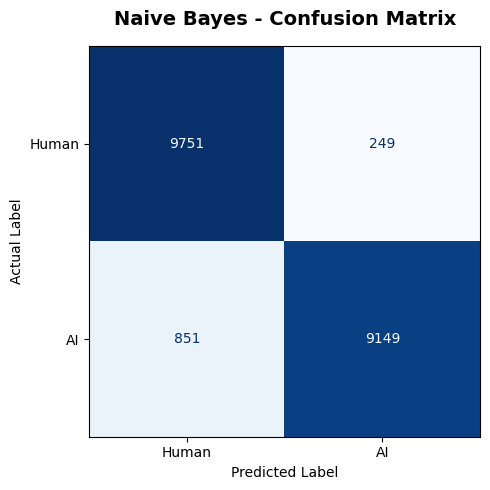

[[9751  249]
 [ 851 9149]]


In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_nb = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Human", "AI"]
)

fig, ax = plt.subplots(figsize=(7, 5))

disp.plot(
    cmap="Blues",
    ax=ax,
    values_format="d",
    colorbar=False
)

plt.title(
    "Naive Bayes - Confusion Matrix",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

print(cm_nb)

models comparison

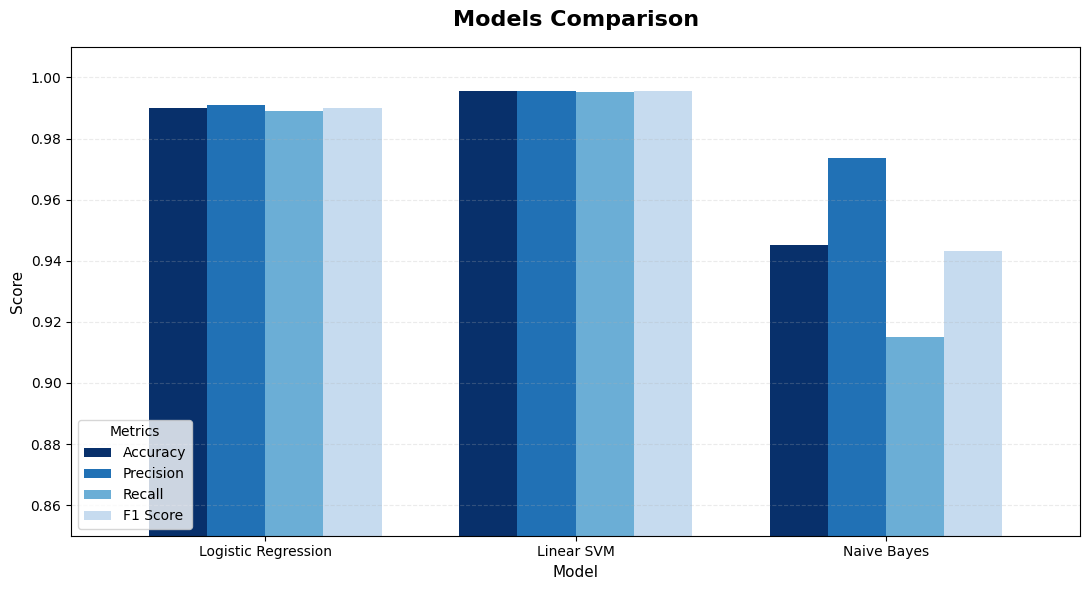

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Naive Bayes"
    ],
    "Accuracy": [
        accuracy,
        svm_accuracy,
        nb_accuracy
    ],
    "Precision": [
        precision,
        svm_precision,
        nb_precision
    ],
    "Recall": [
        recall,
        svm_recall,
        nb_recall
    ],
    "F1 Score": [
        f1,
        svm_f1,
        nb_f1
    ]
})

colors = ["#08306B", "#2171B5", "#6BAED6", "#C6DBEF"]

ax = results.set_index("Model").plot(
    kind="bar",
    figsize=(11, 6),
    color=colors,
    width=0.75
)

plt.title(
    "Models Comparison",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.ylabel("Score", fontsize=11)
plt.xlabel("Model", fontsize=11)

plt.ylim(0.85, 1.01)
plt.xticks(rotation=0)

plt.legend(
    title="Metrics",
    loc="lower left"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()

save svm model because it gave the best results

In [46]:
svm_pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('model', LinearSVC())])

In [47]:
import joblib

joblib.dump(svm_pipeline, "ai_text_detector_svm.pkl")

print("Model saved successfully!")

Model saved successfully!


In [49]:
loaded_model = joblib.load("ai_text_detector_svm.pkl")

print("Model loaded successfully!")

Model loaded successfully!


testing the model

In [50]:
test_text = [
    "I went to the store yesterday and bought some food for dinner."
]

prediction = loaded_model.predict(test_text)

print("Prediction:", prediction)

Prediction: [1.]


In [52]:
test_text = [
    "I was supposed to study yesterday but honestly I spent most of the evening watching videos and then I realized it was already midnight."
]

prediction = loaded_model.predict(test_text)

print("Prediction:", prediction)

Prediction: [1.]


In [53]:
loaded_test_pred = loaded_model.predict(X_test)

from sklearn.metrics import accuracy_score

print("Loaded model accuracy:", accuracy_score(y_test, loaded_test_pred))

Loaded model accuracy: 0.99545


In [54]:
import pandas as pd

print(pd.Series(loaded_test_pred).value_counts())

0.0    10005
1.0     9995
Name: count, dtype: int64


In [55]:
human_samples = df[df["generated"] == 0]["text"].sample(5, random_state=10).tolist()
ai_samples = df[df["generated"] == 1]["text"].sample(5, random_state=10).tolist()

print("HUMAN SAMPLES:")
for text, pred in zip(human_samples, loaded_model.predict(human_samples)):
    print("Prediction:", pred)

print("\nAI SAMPLES:")
for text, pred in zip(ai_samples, loaded_model.predict(ai_samples)):
    print("Prediction:", pred)

HUMAN SAMPLES:
Prediction: 0.0
Prediction: 0.0
Prediction: 0.0
Prediction: 0.0
Prediction: 0.0

AI SAMPLES:
Prediction: 1.0
Prediction: 1.0
Prediction: 1.0
Prediction: 1.0
Prediction: 1.0


In [58]:
test_text = [
        "me and my friend went to the mall last week and we was looking for a new phone but everything was so expensive so i didnt buy anything",
]

prediction = loaded_model.predict(test_text)

print("Prediction:", prediction)

Prediction: [1.]


In [59]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

svm_pipeline_v2 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "model",
        LinearSVC()
    )
])

In [60]:
svm_pipeline_v2.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, min_df=2, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('model', LinearSVC())])

In [61]:
test_text = [
    "me and my friend went to the mall last week and we was looking for a new phone but everything was so expensive so i didnt buy anything"
]

prediction = svm_pipeline_v2.predict(test_text)

print("Prediction:", prediction)

Prediction: [1.]


In [62]:
y_pred_svm_v2 = svm_pipeline_v2.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_svm_v2))
print("Precision:", precision_score(y_test, y_pred_svm_v2))
print("Recall:", recall_score(y_test, y_pred_svm_v2))
print("F1 Score:", f1_score(y_test, y_pred_svm_v2))

Accuracy: 0.9985
Precision: 0.9986994797919168
Recall: 0.9983
F1 Score: 0.998499699939988
